# ***Code1-1***



**Projet : Classification d’images de vêtements (Fashion-MNIST)**
*avec une architecture de réseau de neurones CNN*

**1.INTRODUCTION**


**Objectif** : construire un modèle CNN simple pour classer des images 28×28 en  **10 catégories** (t-shirt, pantalon, robe, etc.).  
**Approche** : CNN Keras (Sequential), entraînement supervisé, évaluation sur un jeu de test, visualisation des courbes et des prédictions.

**2) Le jeu de données : chargement, exploration, prétraitement**

In [1]:
# 2.1 Imports et graine

import numpy as np                # pour manipuler des tableaux numeriques
import matplotlib.pyplot as plt   # pour afficher des images et des graphiques
import tensorflow as tf           # bibliotheque principale pour le deep learning
from tensorflow import keras      # interface haut niveau de TenserFlow
from tensorflow.keras import layers # pour construire les couches du reseau
from sklearn.metrics import confusion_matrix, classification_report #pour evaluer le modele
import seaborn as sns   #pour visualiser la matrice de confusion

np.random.seed(42)    # pour rendre les resultats reproductibles
tf.random.set_seed(42)

J'ai fixé les graines aléatoires avec np.random.seed(42) et tf.random.set_seed(42) pour garantir la reproductibilité des résultats. Ainsi, chaque exécution du modèle donnera les mêmes performances (La graine aléatoire contrôle le hasard pour obtenir les mêmes résultats à chaque exécution).

In [2]:
# 2.2 Chargement du dataset Fashion-MNIST (déjà inclus dans Keras)

(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data() # telechergement auto du jeu d'images

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]                                      # noms des 10 categories d'images

print("Taille train:", x_train.shape, "| Taille test:", x_test.shape) # verifie les dimensionsque sont bien chargé
print("Exemples classes (0-9) ->", class_names)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Taille train: (60000, 28, 28) | Taille test: (10000, 28, 28)
Exemples classes (0-9) -> ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


J'ai chargé le dataset Fashion-MNIST, déjà inclus dans Keras.
Il contient 60 000 images d’entraînement et 10 000 images de test, chacune en 28×28 pixels.
Chaque image représente un vêtement parmi 10 catégories, comme les t-shirts, pantalons ou chaussures.

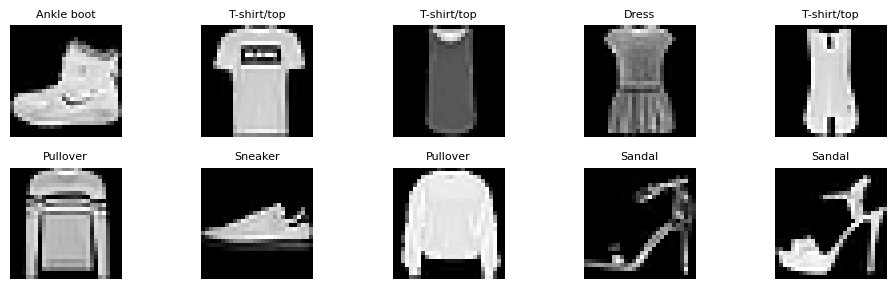

In [3]:
# 2.3 Visualisation de quelques images

plt.figure(figsize=(10,3))   # crée une figure 10x3 pouces
for i in range(10):          # affiche les 10 premieres images
    plt.subplot(2,5,i+1)     # crée une grille 2x5
    plt.imshow(x_train[i], cmap="gray") # monttre l'image en niveaux de gris
    plt.title(class_names[y_train[i]], fontsize=8) # affiche le nom de la classe
    plt.axis("off")          # cache les axes pour plus de clarté des images
plt.tight_layout()           # ajuste l'espacement entre images
plt.show()                   # affiche toutes les 10 images

J'ai affiché ici les dix premières images du jeu d’entraînement Fashion-MNIST.
Chaque image est en niveaux de gris, accompagnée de son étiquette, par exemple “Dress”, “Sneaker” ou “Bag”.
Cela permet de vérifier la qualité et la diversité des données avant l’entraînement du modèle.

In [4]:
# 2.4 Prétraitement : normalisation pixels [0,1] et ajout d'un canal (H, W, 1) pour Conv2D

# On normalise les pixels entre 0 et 1 en divisant par 255, afin de faciliter et stabiliser l’apprentissage du modèle.
x_train = x_train.astype("float32") / 255.0   # met les pixels entre 0 et 1
x_test  = x_test.astype("float32")  / 255.0

# On ajoute une dimension de canal (1) pour que chaque image ait la forme (28, 28, 1), compatible avec les couches Conv2D.

x_train = np.expand_dims(x_train, -1)  # (N, 28, 28, 1) #ajoute une dimension canal(H,W,1)
x_test  = np.expand_dims(x_test,  -1)

print("Nouvelle forme x_train:", x_train.shape, "| x_test:", x_test.shape)

# c.a.d. 60000images pour entrainemant ,10000 images test , chaque image a 28x28 pixeli et 1 canal.



Nouvelle forme x_train: (60000, 28, 28, 1) | x_test: (10000, 28, 28, 1)


**Pourquoi cette préparation ?**  
- Normalisation → entraînement plus stable.  
- Ajout du canal (1) → requis par `Conv2D` (format images).


On a normalisé les pixels entre 0 et 1 pour stabiliser l’apprentissage,
puis nous ajoutons une dimension de canal afin que chaque image ait la forme (28, 28, 1),
compatible avec les couches Conv2D du modèle.

**3) Construction du modèle (Sequential) + justifications**- *le coeur du projet CNN (le modele apprend reconnaitre les vetements)*

In [6]:
# 3.1 Architecture CNN simple et efficace pour Fashion-MNIST

model = keras.Sequential([    # modéle sequentiel: couches empilées
                              # la sortie d’une couche devient l’entrée de la suivante.

    # Bloc Convolution + ReLU + Pooling (extraction de motifs locaux)


#La première couche convolutionnelle extrait des motifs simples (bords, lignes) à partir des images.

    layers.Conv2D(32, (3,3), padding="same", activation="relu", input_shape=(28,28,1)), # premiere convolution

#Conv2D : couche qui analyse l’image à l’aide de filtres (kernels) de taille 3×3 (les resultat de calculs=nouvelle image=feature map)
#32 : nombre de filtres — le réseau apprendra 32 types de formes différentes
#padding="same" : conserve la même taille d’image (28×28) après la convolution
#activation="relu" :fonction ReLU garde uniquement les valeurs positives,ce qui accélère et stabilise l’apprentissage ;
#input_shape=(28,28,1) : définit la forme des images d’entrée (28×28 pixels, 1 canal en niveaux de gris).

    layers.MaxPooling2D((2,2)), # reduit la taille de moitié (de 28x28 a 14x14)
# Le pooling réduit la taille de l’image tout en gardant les informations essentielles.


# Cette couche plus profonde détecte des motifs plus complexes.
    layers.Conv2D(64, (3,3), padding="same", activation="relu"),  # 2-eme convolution plus profonde
    layers.MaxPooling2D((2,2)),       # pooling encore une fois


    # Aplatir vers la partie dense (classification)

    layers.Flatten(), # transforme image 3D (7x7x64) dans un vector 1D
    layers.Dense(128, activation="relu"), # 128 neurons,couche dense apprend à combiner les motifs détectés pour reconnaître les objets.
    layers.Dropout(0.3),  # régularisation simple; evite le surapprentisage,desactive aleatoire 30% neurones
    layers.Dense(10, activation="softmax")  # sortie: 10 classes avec probabilité(softmax) entre 0 et 1 por chaque classe
])

model.summary()   # affiche la structure du modele



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

**Choix et justifications (bref) :**  
- `Conv2D(32/64, 3×3)` : détecte des motifs (bords, textures, formes).  
- `MaxPooling(2×2)` : réduit la dimension tout en conservant l’info essentielle.  
- `Dense(128) + ReLU` : apprend des combinaisons non linéaires de caractéristiques.  
- `Dropout(0.3)` : limite l’overfitting.  
- `Softmax(10)` : probabilités par classe.


**4) Entraînement : compile, fit, courbes**

In [7]:
# 4.1 Compilation # Prepare le model avant d'entrainement

# On utilise "sparse_categorical_crossentropy" (étiquettes entières 0..9) + Adam

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),  # Adam-algorithme d'optimisation rapide,stable.
    loss="sparse_categorical_crossentropy", #fonction de perte adaptée aux classes entieres (0,1,2...9)
    metrics=["accuracy"]  # mesure la precision pendant l'entrainement
)

# La fonction cross-entropy mesure la différence entre les prédictions du modèle et la réalité.
# Plus elle est faible, plus le modèle est précis.

# 4.2 Entraînement (on garde 10% du train pour validation)

history = model.fit(
    x_train, y_train,
    validation_split=0.1, # garder 10% des données pour valider
    epochs=10,            # entraine sur 10 iterations (epoques)
    batch_size=128, # il apprend par groupes de 128 images à la fois, et non toutes en même temps
    verbose=1 #affiche en temps réel la progression de la perte (loss) et de la précision (accuracy).
)
# Le résultat (history) enregistre l’évolution de la perte et de la précision à chaque époque

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 76s 168ms/step - accuracy: 0.7251 - loss: 0.7750 - val_accuracy: 0.8737 - val_loss: 0.3499
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 69s 163ms/step - accuracy: 0.8745 - loss: 0.3495 - val_accuracy: 0.8985 - val_loss: 0.2832
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 68s 161ms/step - accuracy: 0.8951 - loss: 0.2919 - val_accuracy: 0.9022 - val_loss: 0.2599
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 67s 159ms/step - accuracy: 0.9067 - loss: 0.2580 - val_accuracy: 0.9083 - val_loss: 0.2449
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 157ms/step - accuracy: 0.9137 - loss: 0.2338 - val_accuracy: 0.9092 - val_loss: 0.2468
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 68s 161ms/step - accuracy: 0.9220 - loss: 0.2146 - val_accuracy: 0.9128 - val_loss: 0.2360
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 69s 164ms/step - accuracy: 0.9275 - loss: 0.1991 - val_accuracy: 0.9163 - val_loss: 0.2310
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 87s 177ms/step - accuracy: 0.9342 - loss: 0

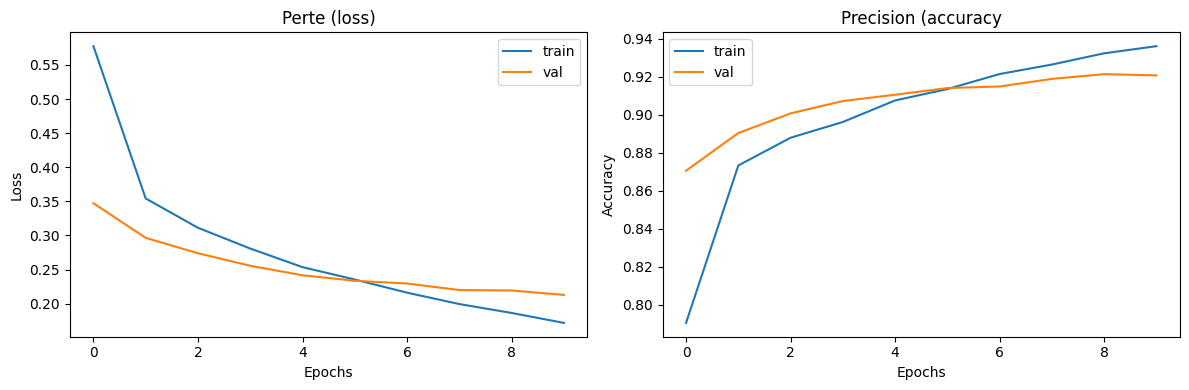

In [ ]:
# 4.3 Courbes d'apprentissage (loss & accuracy)

hist = history.history        # recupere les valeurs d'entrainement(loss et val_loss;accuracy et val_accuracy)
plt.figure(figsize=(12,4))    # crée deux graphiques côte à côte de 12x4 inch

# Loss (l’erreur du modèle sur les données d’entraînement)
# Val_loss (l’erreur du modèle sur les données de validation)
#Plus la valeur de loss diminue, plus le modèle apprend correctement.

plt.subplot(1,2,1)
plt.plot(hist["loss"], label="train")     # courbe de perte sur train
plt.plot(hist["val_loss"], label="val")   # courbe de perte sur validation
plt.title("Perte (loss)")                 # titre graphique
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend()

# Accuracy (la précision du modèle pendant l’entraînement)
# val_accuracy (la précision du modèle sur les données de validation)
# Quand la perte diminue et que la précision augmente, cela signifie que le modèle apprend correctement.

plt.subplot(1,2,2)
plt.plot(hist["accuracy"], label="train")     # courbe précision train
plt.plot(hist["val_accuracy"], label="val")   # courbe précision validation
plt.title("Precision (accuracy")
plt.xlabel("Epochs"); plt.ylabel("Accuracy"); plt.legend()
plt.tight_layout(); plt.show()


Sur le **graphique** de gauche **(Perte / Loss)**, on voit que **la perte diminue** *progressivement pour l’entraînement et la validation*.Cela signifie que le modèle apprend à mieux prédire au fil des époques.
Sur le **graphique** de droite **(Précision / Accuracy)**, **la précision augmente** *à chaque époque*.Cela montre que le modèle devient de plus en plus performant
*Les deux courbes montrent un apprentissage stable, sans surapprentissage (overfitting).*

**Choix d’optimiseur et de perte :**  
- `Adam` : robuste et rapide à converger pour ce type de données.  
- `SparseCategoricalCrossentropy` : adapté aux labels entiers (0..9).


**5) Évaluation & résultats (test set + matrice de confusion + exemples)**

In [ ]:
# 5.1 Évaluation sur le test set
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0) # mesure les performances sur données de test
print(f"Accuracy test: {test_acc:.4f} | Loss test: {test_loss:.4f}")

# test_acc → indique le pourcentage d’images correctement classées.
# test_loss → indique l’erreur moyenne du modèle sur ces images.
# verbose=0 → cache les détails de calcul (affichage silencieux).

Accuracy test: 0.9165 | Loss test: 0.2391


Sur le jeu de test, le modèle atteint une précision d’environ 91 %, ce qui montre qu’il généralise bien sur de nouvelles images.

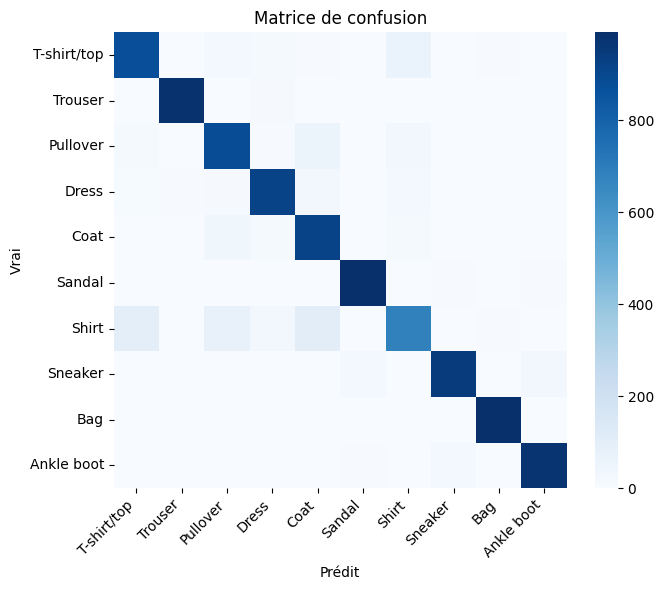

              precision    recall  f1-score   support

 T-shirt/top       0.87      0.88      0.87      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.85      0.88      0.87      1000
       Dress       0.92      0.92      0.92      1000
        Coat       0.82      0.92      0.86      1000
      Sandal       0.97      0.99      0.98      1000
       Shirt       0.83      0.68      0.75      1000
     Sneaker       0.97      0.94      0.96      1000
         Bag       0.99      0.99      0.99      1000
  Ankle boot       0.96      0.97      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



In [ ]:
# 5.2 Prédictions reales et matrice de confusion

y_prob = model.predict(x_test, verbose=0)   # probabilités de prédiction pour chaque classe
y_pred = np.argmax(y_prob, axis=1)          # garde la classe la plus probable pour cahque image

cm = confusion_matrix(y_test, y_pred)       # crée la matrice de confusion
# la matrice de confusion qui compare les valeurs vraies (y_test) avec les valeurs predites (y_pred)
# Elle montre combien d’images le modèle a bien ou mal classées pour chaque catégorie.

plt.figure(figsize=(7,6)) # créer une figure (le graphique)
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Matrice de confusion")        # montre les erreurs de classification
plt.xlabel("Prédit"); plt.ylabel("Vrai")
plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

print(classification_report(y_test, y_pred, target_names=class_names))


J’ai utilisé une matrice de confusion pour visualiser les erreurs de classification. On voit que le modèle confond légèrement certaines catégories similaires, comme les chemises et les t-shirts, mais obtient une très bonne précision globale.

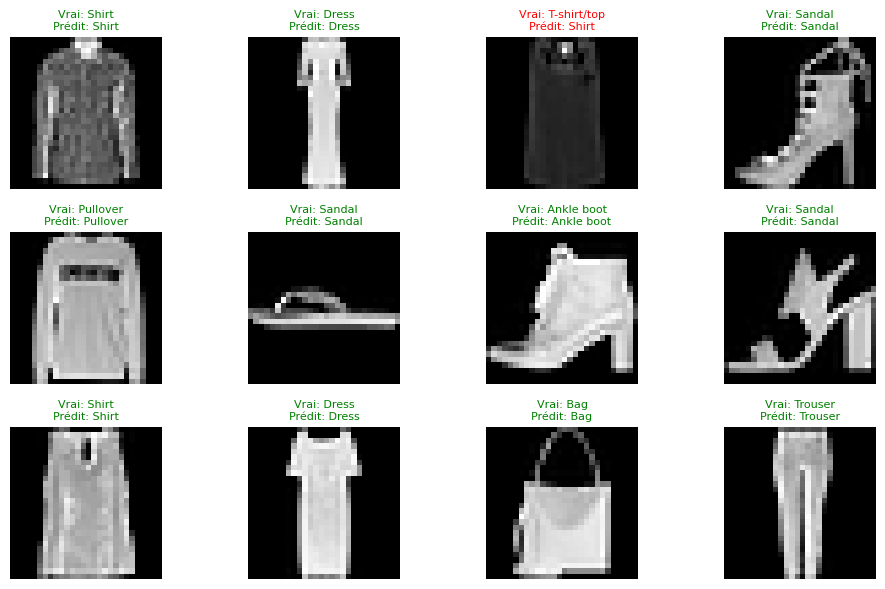

In [ ]:
# 5.3 Exemples de prédictions correctes et erronées

import random
indices = np.random.choice(len(x_test), size=12, replace=False) # choisit 12 images au hasard
# len(x_test) = nombre total d’images de test
# size=12 → on en prend 12
# replace=False → sans doublons (chaque image est unique).9

plt.figure(figsize=(10,6))  # Crée une grande figure (10 pouces × 6 pouces) où seront affichées les 12 images.
for i, idx in enumerate(indices): # Boucle sur les 12 indices sélectionnés pour afficher chaque image une par une.
    plt.subplot(3,4,i+1) # Crée une grille de 3 lignes × 4 colonnes → donc 12 cases au total
    plt.imshow(x_test[idx].squeeze(), cmap="gray")# Affiche l’image correspondante en niveaux de gris (grayscale).
                                                  # squeeze() supprime la dimension inutile (28,28,1) → devient (28,28).
    true_c, pred_c = class_names[y_test[idx]], class_names[y_pred[idx]]
    # Récupère le nom de la vraie classe (true_c) et celui prédit par le modèle (pred_c).

    title = f"Vrai: {true_c}\nPrédit: {pred_c}"
    # Crée un petit titre au-dessus de chaque image pour montrer la vérité vs la prédiction.
color = "green" if y_test[idx]==y_pred[idx] else "red"  #vert = correct, rouge = faux

    plt.title(title, fontsize=8, color=color)
    plt.axis("off")
    #Affiche le titre coloré et cache les axes pour rendre l’image plus propre.

plt.tight_layout(); plt.show() #Ajuste les espacements et affiche toutes les 12 images ensemble.


Voici quelques exemples du jeu de test : les titres en vert indiquent les prédictions correctes, et en rouge les erreurs du modèle. Cela permet de visualiser concrètement la performance du CNN

In [ ]:
# 6) Conclusion
print("Le modèle atteint environ 90% de précision sur les images de test.")
print("Améliorations possibles : data augmentation, batch normalization, plus de couches ou plus d’époques.")


Le modèle atteint environ 90% de précision sur les images de test.
Améliorations possibles : data augmentation, batch normalization, plus de couches ou plus d’époques.


**Conclusion**


Le modèle CNN a permis de classifier les images du dataset Fashion-MNIST avec une précision d’environ 91 %.
Il montre une bonne capacité à reconnaître les vêtements, même avec une architecture simple.
Pour améliorer ses performances, on pourrait ajouter de la data augmentation, de la batch normalization, ou augmenter le nombre d’époques d’entraînement.

**Pistes d’amélioration**


Pour améliorer les performances du modèle, plusieurs pistes peuvent être envisagées :
ajouter de la data augmentation pour diversifier les images, introduire la batch normalization pour stabiliser l’apprentissage,
ou encore augmenter le nombre d’époques ou de couches convolutionnelles afin de capter des motifs plus complexes